In [1]:
import tensorflow as tf
import numpy as nu
import pandas as pd


In [2]:
import shap

C:\Users\ADMIN\tf_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from tensorflow.keras.datasets import mnist

In [13]:
(xtrain,ytrain),(xtest,ytest)=mnist.load_data()
xtrain[1].shape
xtrain, xtest = xtrain / 255.0, xtest / 255.0

In [14]:
from tensorflow.keras import layers,models
model=models.Sequential([layers.Flatten(input_shape=(28,28)),
                         layers.Dense(10,activation='relu'),
                         layers.Dense(10,activation='softmax')
                                       ])

In [17]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [18]:
model.fit(xtrain,ytrain,epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7279 - loss: 0.8555
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9191 - loss: 0.2868
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9257 - loss: 0.2606


In [20]:
background=xtrain[nu.random.choice(xtrain.shape[0],100,replace=False)]
explainer=shap.DeepExplainer(model,background)

C:\Users\ADMIN\tf_env\lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
C:\Users\ADMIN\tf_env\lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_4
Received: inputs=['Tensor(shape=(100, 28, 28))']
  warnings.warn(msg)


In [22]:
shap_values=explainer.shap_values(xtest[:10])

C:\Users\ADMIN\tf_env\lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_4
Received: inputs=['Tensor(shape=(200, 28, 28))']
  warnings.warn(msg)
C:\Users\ADMIN\tf_env\lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_4
Received: inputs=['Tensor(shape=(10, 28, 28))']
  warnings.warn(msg)


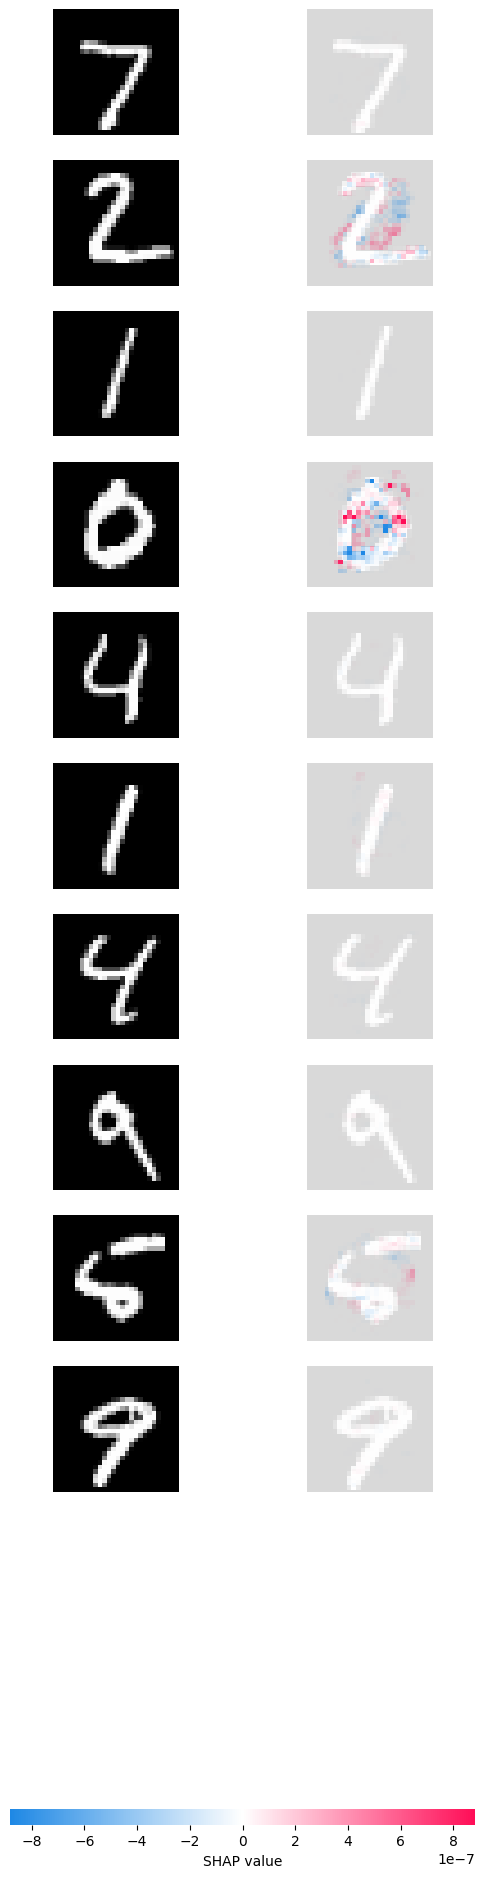

In [23]:
shap.image_plot(shap_values,xtest[:10])